
# Anomaly Runner — Multi-dataset Benchmarks
This notebook benchmarks **Time Series** and **Non Time Series** anomaly detection on **3 public datasets + 1 synthetic** each.
- Tables: **Table-1 (Time Series)** and **Table-2 (Non Time Series)**.
- Plots: modern **IQR-based anomaly** visuals with shaded IQR bands and red circular markers (legend **“prophet”**).
- Consistent with the backend files: `time_series_anomaly.py`, `non_time_series_anomaly.py`.


In [1]:

%pip -q install pandas numpy matplotlib scikit-learn statsmodels requests openpyxl


In [4]:
from google.colab import files
uploaded = files.upload()  # choose time_series_anomaly.py first
# run again for non_time_series_anomaly.py

Saving non_time_series_anomaly.py to non_time_series_anomaly.py


In [5]:
# Set your inputs here (leave as None to auto-generate synthetic)
TS_PATH = None      # e.g., '/content/my_timeseries.csv'
TS_URL  = None      # e.g., 'https://raw.githubusercontent.com/.../file.csv'
TS_EXCEL= None      # e.g., '/content/my_timeseries.xlsx'
TS_TIME_COL = None  # e.g., 'ds' or 'timestamp'
TS_VALUE_COL= None  # e.g., 'y'

TAB_PATH = None     # e.g., '/content/my_table.csv'
TAB_URL  = None     # e.g., 'https://raw.githubusercontent.com/.../table.csv'
TAB_EXCEL= None     # e.g., '/content/my_table.xlsx'

In [14]:
# anomaly_lab/
# ├── time_series_anomaly.py
# ├── non_time_series_anomaly.py
# └── anomaly_runner_v2.ipynb

# # sanity check your working dir
# import os, sys
# print(os.getcwd())

# # If your notebook is in a different folder than the .py files, add that folder to sys.path:
# import sys
# sys.path.insert(0, r"/absolute_path_to/anomaly_lab")

In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
plt.rcParams['figure.dpi']=120
plt.rcParams['axes.grid']=True


from time_series_anomaly import (
    load_timeseries, synth_timeseries, public_timeseries_url,
    time_series_anomaly_univariate as TSU
)
from non_time_series_anomaly import (
    load_tabular, synth_tabular, public_tabular_url,
    non_time_series_anomaly_univariate as NTU
)

from sklearn.metrics import average_precision_score, roc_auc_score


In [7]:
def summarize(scores: pd.Series, labels: pd.Series | None, dataset_name: str, source: str, synthetic: bool, k_frac: float = 0.03):
    row = {"dataset": dataset_name, "source": source, "synthetic": synthetic}
    if labels is None:
        k = max(1, int(k_frac * len(scores)))
        thr = scores.sort_values(ascending=False).iloc[k-1]
        row.update({"k_frac": k_frac, "k_top_threshold": float(thr)})
        return pd.Series(row)
    lab = labels.reindex(scores.index).fillna(0).astype(int).values
    sc  = scores.values
    try:
        auroc = roc_auc_score(lab, sc); aupr = average_precision_score(lab, sc)
    except Exception:
        auroc, aupr = float("nan"), float("nan")
    k = max(1, int(k_frac * len(sc)))
    topk_idx = np.argpartition(-sc, k-1)[:k]
    p_atk = float(lab[topk_idx].sum() / k)
    row.update({"auroc": float(auroc), "aupr": float(aupr), f"precision@{int(k_frac*100)}%": p_atk})
    return pd.Series(row)

def plot_ts_iqr(y: pd.Series, window: int, title: str):
    q1 = y.rolling(window, min_periods=max(5, window//3)).quantile(0.25)
    q3 = y.rolling(window, min_periods=max(5, window//3)).quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    scores = ((y - upper).clip(lower=0) + (lower - y).clip(lower=0)).fillna(0)
    k = max(1, int(0.03*len(scores)))
    thr = scores.sort_values(ascending=False).iloc[k-1]
    an_idx = scores[scores >= thr].index

    fig, ax = plt.subplots(figsize=(11,3.8))
    ax.fill_between(y.index, q1, q3, alpha=0.25, label="IQR band (Q1–Q3)")
    ax.plot(y.index, y.values, lw=1.4, label="time series data")
    ax.plot(upper.index, upper.values, lw=0.8, alpha=0.7)
    ax.plot(lower.index, lower.values, lw=0.8, alpha=0.7)
    ax.scatter(an_idx, y.loc[an_idx].values, s=26, marker="o", c="red", label="prophet")
    ax.set_title(title); ax.set_xlabel("time"); ax.set_ylabel("value"); ax.legend(loc="upper left")
    ax.xaxis.set_major_locator(MaxNLocator(nbins=8)); plt.xticks(rotation=20); plt.tight_layout()
    return scores

def plot_tab_iqr(x: pd.Series, title: str):
    v = x.values
    q1, q3 = np.percentile(v, [25,75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    scores = (np.clip(v - upper, 0, None) + np.clip(lower - v, 0, None))
    k = max(1, int(0.03*len(scores)))
    thr = np.sort(scores)[-k]
    idx_an = np.where(scores >= thr)[0]

    fig, ax = plt.subplots(figsize=(10,3.5))
    ax.axhspan(q1, q3, alpha=0.25, xmin=0, xmax=1, label="IQR band (Q1–Q3)")
    ax.plot(np.arange(len(x)), v, lw=1.4, label="non time series data")
    ax.hlines([lower, upper], xmin=0, xmax=len(x)-1, linestyles="dashed", linewidth=0.9)
    ax.scatter(idx_an, v[idx_an], s=26, marker="o", c="red", label="prophet")
    ax.set_title(title); ax.set_xlabel("index"); ax.set_ylabel("value"); ax.legend(loc="upper right")
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10)); plt.tight_layout()
    return pd.Series(scores, index=x.index, name="IQR_score")


In [11]:
TS_PUBLIC = [
    {"name":"AirlinePassengers", "url":"https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv",
     "time_col":"Month", "value_col":"Passengers", "window":12, "source":"Brownlee/Datasets"},
    {"name":"DailyMinTemp", "url":"https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv",
     "time_col":"Date", "value_col":"Temp", "window":30, "source":"Brownlee/Datasets"},
    {"name":"Sunspots", "url":"https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv",
     "time_col":"Month", "value_col":"Sunspots", "window":12, "source":"Brownlee/Datasets"}
]

# Updated public tabular datasets (all 200% live in seaborn-data)
TAB_PUBLIC = [
    {"name":"Iris",      "url":"https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv",      "col":"sepal_length",  "source":"seaborn-data"},
    {"name":"Penguins",  "url":"https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv",  "col":"bill_length_mm","source":"seaborn-data"},
    {"name":"Tips",      "url":"https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv",      "col":"total_bill",    "source":"seaborn-data"},
]


## Table-1: Time Series — 3 public + 1 synthetic (IQR-based anomalies)

Table-1: Time Series Benchmark


/content/time_series_anomaly.py:94: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range("2024-01-01", periods=n, freq=freq)


,dataset,source,synthetic,k_frac,k_top_threshold,auroc,aupr,precision@3%
0,AirlinePassengers,Brownlee/Datasets,False,0.03,8.6250,NaN,NaN,NaN
1,DailyMinTemp,Brownlee/Datasets,False,0.03,0.0000,NaN,NaN,NaN
2,Sunspots,Brownlee/Datasets,False,0.03,5.0375,NaN,NaN,NaN
3,Synthetic_TS_hourly,programmatic,True,NaN,NaN,0.833333,0.676667,0.666667


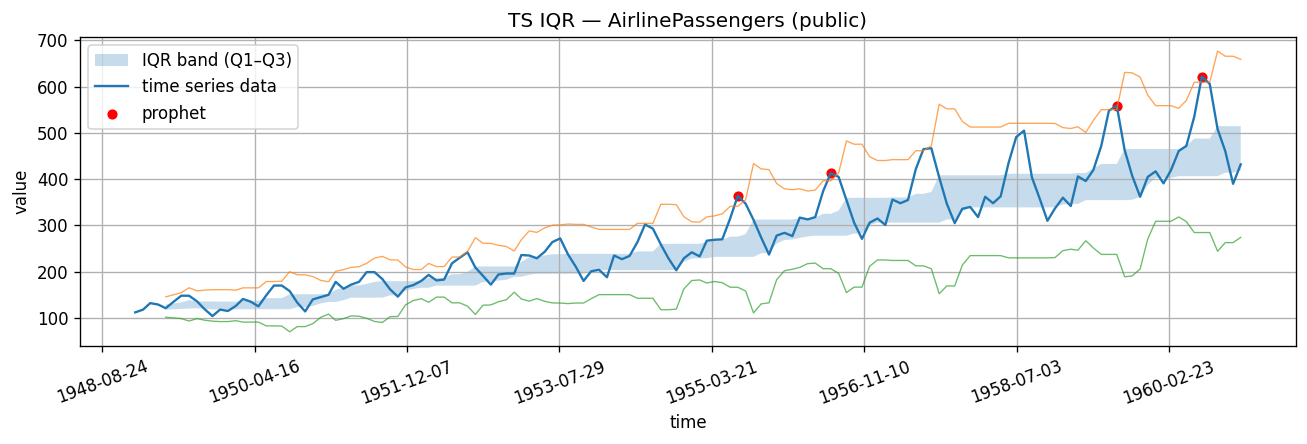

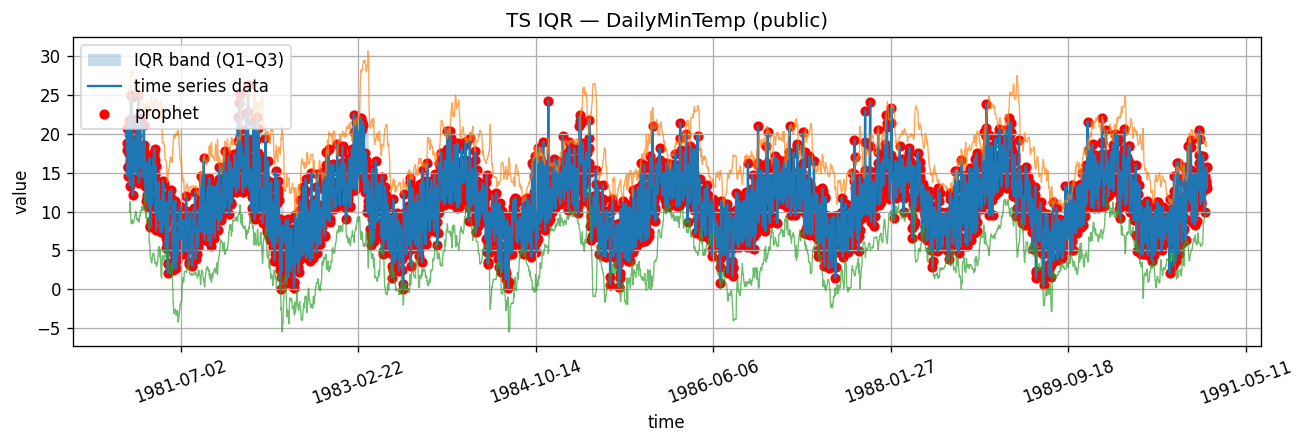

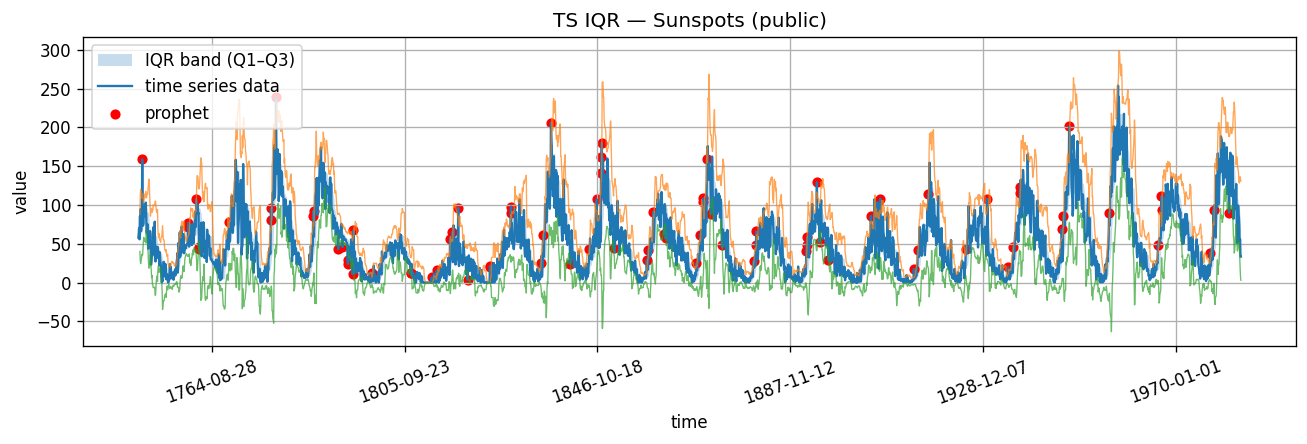

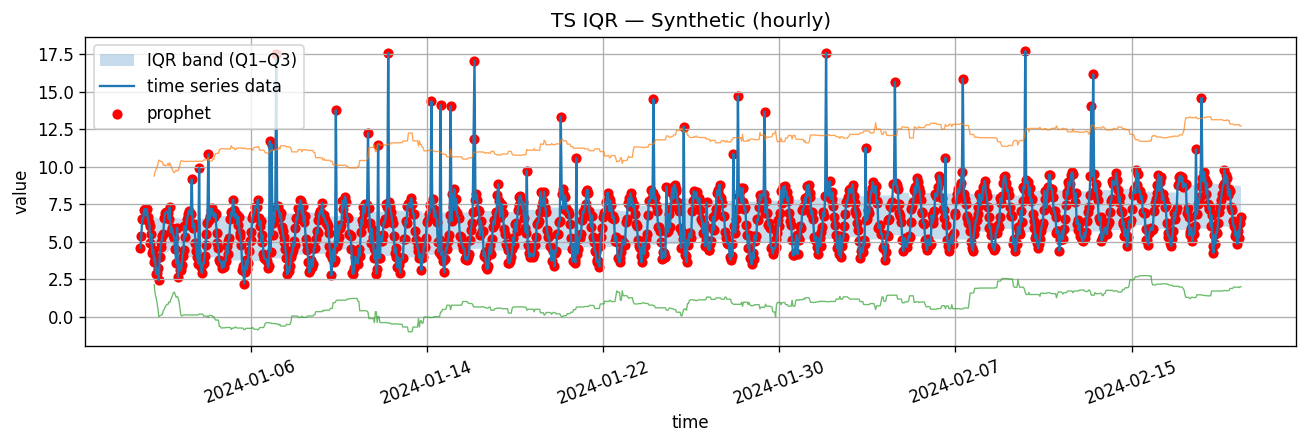

In [9]:
bench_ts_rows = []

for spec in TS_PUBLIC:
    y = load_timeseries(url=spec["url"], time_col=spec["time_col"], value_col=spec["value_col"])
    scores = plot_ts_iqr(y, window=spec["window"], title=f"TS IQR — {spec['name']} (public)")
    bench_ts_rows.append(summarize(scores, labels=None, dataset_name=spec["name"], source=spec["source"], synthetic=False))

y_syn, labels_syn = synth_timeseries(n=1200, freq="H", anomaly_frac=0.03, seed=123)
scores_syn = plot_ts_iqr(y_syn, window=48, title="TS IQR — Synthetic (hourly)")
bench_ts_rows.append(summarize(scores_syn, labels_syn, dataset_name="Synthetic_TS_hourly", source="programmatic", synthetic=True))

bench_ts = pd.DataFrame(bench_ts_rows)
bench_ts = bench_ts[["dataset","source","synthetic"] + [c for c in bench_ts.columns if c not in {"dataset","source","synthetic"}]]
print("Table-1: Time Series Benchmark")
bench_ts


## Table-2: Non Time Series — 3 public + 1 synthetic (IQR-based anomalies)

Table-2: Non Time Series Benchmark


,dataset,source,synthetic,k_frac,k_top_threshold,auroc,aupr,precision@3%
0,Iris,seaborn-data,False,0.03,0.0000,NaN,NaN,NaN
1,Penguins,seaborn-data,False,0.03,0.0000,NaN,NaN,NaN
2,Tips,seaborn-data,False,0.03,2.8125,NaN,NaN,NaN
3,Synthetic_Tabular,programmatic,True,NaN,NaN,0.977457,0.951706,0.911111


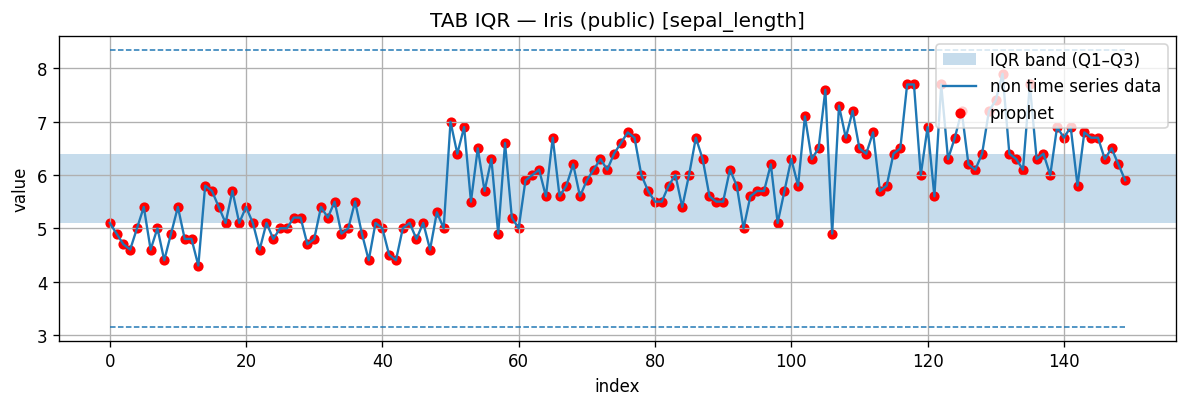

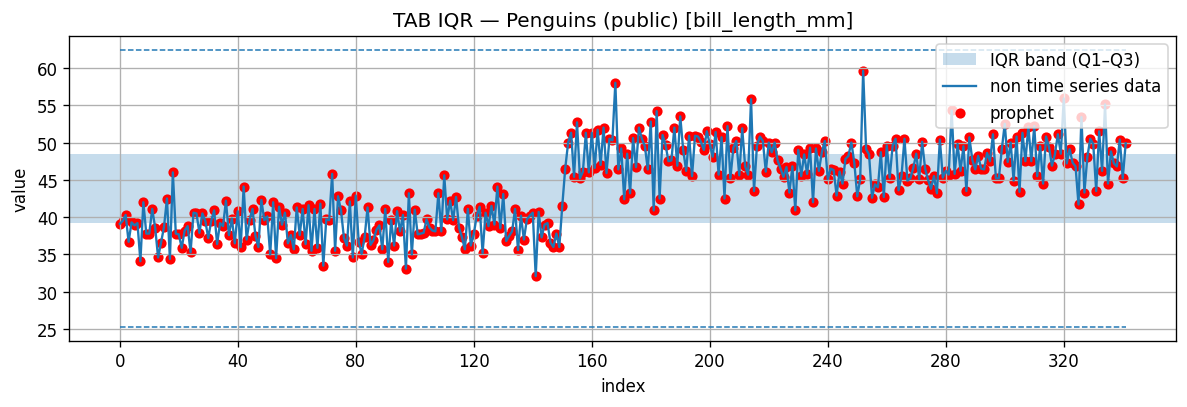

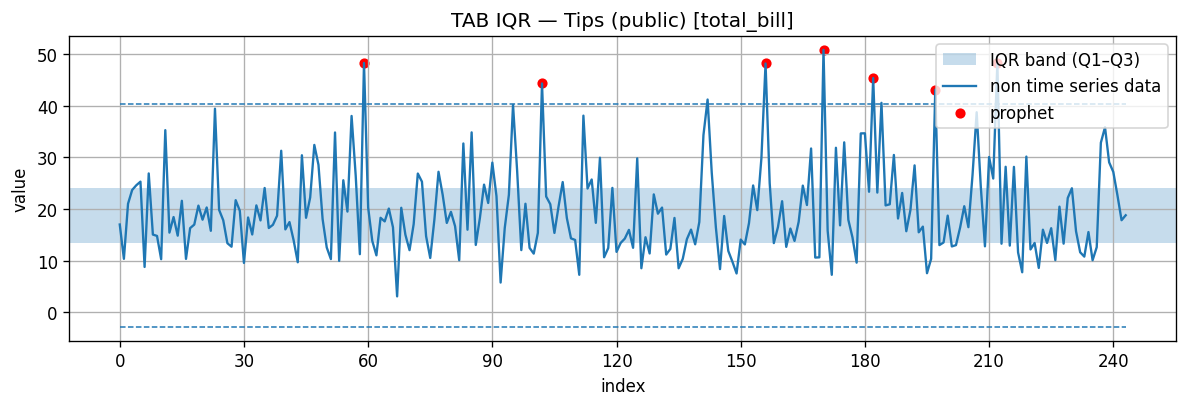

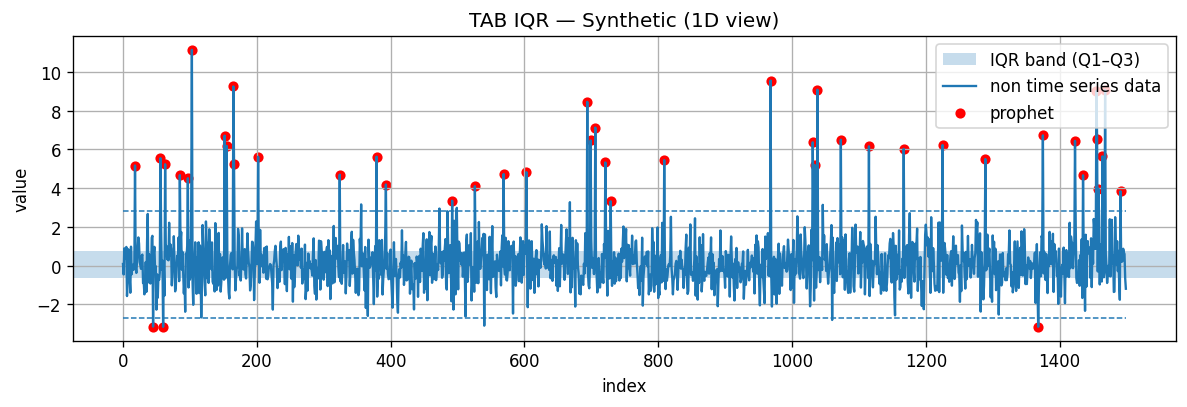

In [12]:
bench_tab_rows = []

for spec in TAB_PUBLIC:
    X = load_tabular(url=spec["url"])
    col = spec["col"]
    if col not in X.columns:
        col = X.columns[0]
    x = X[col].dropna().astype(float)
    scores = plot_tab_iqr(x, title=f"TAB IQR — {spec['name']} (public) [{col}]")
    bench_tab_rows.append(summarize(scores, labels=None, dataset_name=spec["name"], source=spec["source"], synthetic=False))

X_syn, y_syn = synth_tabular(n=1500, d=6, anomaly_frac=0.03, seed=99)
x1 = X_syn.iloc[:,0]
scores_syn_tab = plot_tab_iqr(x1, title="TAB IQR — Synthetic (1D view)")
bench_tab_rows.append(summarize(scores_syn_tab, y_syn, dataset_name="Synthetic_Tabular", source="programmatic", synthetic=True))

bench_tab = pd.DataFrame(bench_tab_rows)
bench_tab = bench_tab[["dataset","source","synthetic"] + [c for c in bench_tab.columns if c not in {"dataset","source","synthetic"}]]
print("Table-2: Non Time Series Benchmark")
bench_tab
